In [40]:
import pandas as pd

In [41]:
raw = pd.read_csv("/work/E26-experimental-psycholinguistics/natural_unnatural_experiment/combined_data.csv")

In [42]:
#raw.head(20)
# shows you the first x number of rows. default is 5 rows
#raw.head()

In [43]:
#raw.tail()
# .tail shows you the last rows of the data

In [44]:
list(raw)
#gives you a list of all the column names

['participant_id',
 'component_num',
 'url',
 'meta',
 'sender',
 'sender_type',
 'sender_id',
 'ended_on',
 'duration',
 'time_run',
 'time_render',
 'time_show',
 'time_end',
 'time_commit',
 'timestamp',
 'time_switch',
 'response',
 'response_action',
 'prime',
 'target',
 'condition',
 'soa_condition',
 'congruence',
 'correct_response',
 'correctResponse',
 'correct']

IVs - SOA, congruens

DVs - response time, accuracy

In [45]:
cols = ['participant_id', "sender", "duration", "response", "condition", "soa_condition", "congruence", "correctResponse", "correct", "target", "prime"]

In [46]:
data = raw[cols]
data

,participant_id,sender,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime
0,51,Wecome1,499.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,51,Wecome2,499.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51,Wecome3,499.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,51,Instructions1,9061.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,51,Instructions 1a,2279.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
15632,69,Short Loop,85426.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15633,69,Break,868.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15634,69,Short Sequence,86318.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15635,69,Experiment Sequence,183618.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
data = data[data["sender"] == "target"]
# == means "is equal to", whereas = is assigning a value
# so this command only shows where the sender column has target as a value
data

,participant_id,sender,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime
13,51,target,843.38,n,practice,practice,practice,n,True,SHEEP,snjghf
19,51,target,593.04,m,practice,practice,practice,m,True,BOAT,iweonf
25,51,target,559.18,m,practice,practice,practice,m,True,HOUSE,nvoiuh
31,51,target,653.76,n,practice,practice,practice,n,True,HORSE,abjdhjs
40,51,target,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt
15612,69,target,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy
15618,69,target,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach
15624,69,target,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake


In [48]:
sender_list = list(data["sender"])
sender_list
#this runs about a million lines of output. to condense it, we make it into a set
set(sender_list)

{'target'}

In [49]:
data["sender"].unique()

<StringArray>
['target']
Length: 1, dtype: str

In [50]:
data = data[data["condition"] !="practice"]
data
#shows all the values of the condition column that are NOT practice

,participant_id,sender,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime
40,51,target,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof
47,51,target,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,BULL,sheep
54,51,target,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,GOAT,fort
61,51,target,495.68,n,Con_Nat,long,congruent,n,True,PEAR,pear
68,51,target,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,MOTOR,olive
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt
15612,69,target,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy
15618,69,target,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach
15624,69,target,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake


In [51]:
data = data.drop(columns = ["sender"])
# removing sender because we know that it just says target every time. we know this from running the sender_list function
data

,participant_id,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime
40,51,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof
47,51,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,BULL,sheep
54,51,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,GOAT,fort
61,51,495.68,n,Con_Nat,long,congruent,n,True,PEAR,pear
68,51,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,MOTOR,olive
...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt
15612,69,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy
15618,69,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach
15624,69,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake


In [52]:
# i now cannot run the cell above without it showing an error because it then tries to remove a column that is already removed 

In [53]:
data.loc[data["target"] == "BULL", "correct_response"] = "n"
data

,participant_id,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime,correct_response
40,51,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof,NaN
47,51,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,BULL,sheep,n
54,51,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,GOAT,fort,NaN
61,51,495.68,n,Con_Nat,long,congruent,n,True,PEAR,pear,NaN
68,51,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,MOTOR,olive,NaN
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt,NaN
15612,69,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy,NaN
15618,69,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach,NaN
15624,69,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake,NaN


In [56]:
data["accuracy"] = data["response"] == data["correct_response"]
# making a new column to check whether the response is correct
data

,participant_id,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime,correct_response,accuracy
40,51,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof,NaN,False
47,51,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,BULL,sheep,n,True
54,51,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,GOAT,fort,NaN,False
61,51,495.68,n,Con_Nat,long,congruent,n,True,PEAR,pear,NaN,False
68,51,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,MOTOR,olive,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
15606,69,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt,NaN,False
15612,69,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy,NaN,False
15618,69,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach,NaN,False
15624,69,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake,NaN,False


In [57]:
data_grouped = data.groupby(["soa_condition", "congruence"]).mean(["duration"])
# everyone has got this error and we dont know why. ethan is going to fix it at some point

ValueError: numeric_only accepts only Boolean values

In [62]:
data_grouped = data

In [65]:
data_grouped = data_grouped.reset_index()
data_grouped

,level_0,index,participant_id,duration,response,condition,soa_condition,congruence,correctResponse,correct,target,prime,correct_response,accuracy
0,0,40,51,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,PIANO,roof,NaN,False
1,1,47,51,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,BULL,sheep,n,True
2,2,54,51,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,GOAT,fort,NaN,False
3,3,61,51,495.68,n,Con_Nat,long,congruent,n,True,PEAR,pear,NaN,False
4,4,68,51,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,MOTOR,olive,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,2275,15606,69,699.20,m,Con_Synth,short,congruent,m,True,BELT,belt,NaN,False
2276,2276,15612,69,580.20,n,Con_Nat,short,congruent,n,True,DAISY,daisy,NaN,False
2277,2277,15618,69,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,SHED,peach,NaN,False
2278,2278,15624,69,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,HUSKY,rake,NaN,False


In [67]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [68]:
import seaborn as sns
# a new library that makes matplotlib library simpler

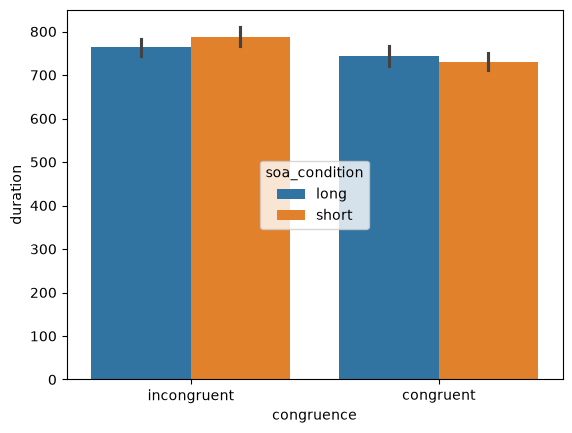

In [74]:
ax = sns.barplot(data = data_grouped, x = "congruence", y = "duration", hue = "soa_condition")
sns.move_legend(ax, "center")